# SE ResNet18 Architecture

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[2]
sys.path.append(str(PROJECT_ROOT))
print(PROJECT_ROOT)

C:\Users\markm\Workspace\ms-machine-learning-diagnosis


In [2]:
import refactor.src.data as data
import refactor.src.models as models
import refactor.src.trainer as trainer
import refactor.src.evaluator as evaluator

## Data Acquisition & Processing

get_dataset()>>> Dataset already exists in ../../../data/raw
get_dataset()>>> Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']
get_classes()>>> Visualising sample images from each category...


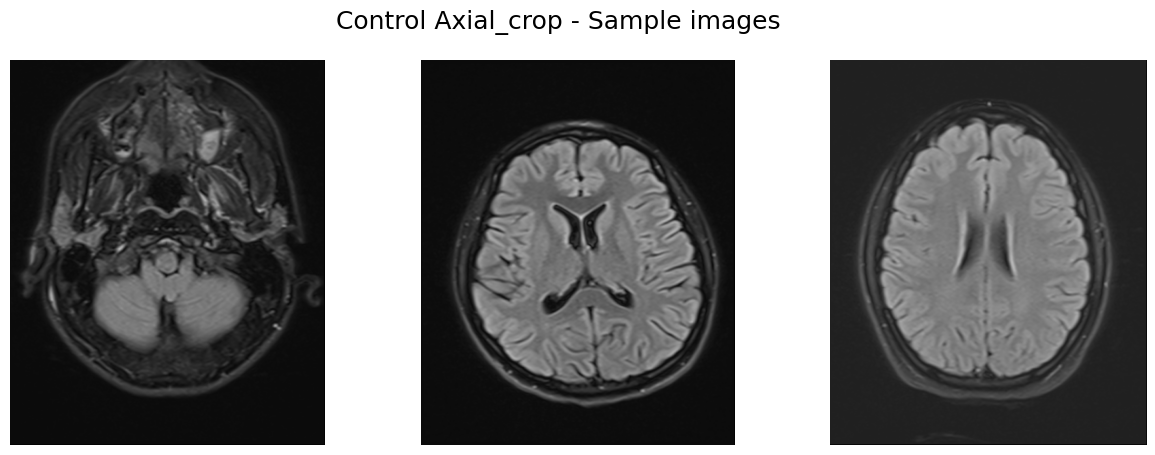

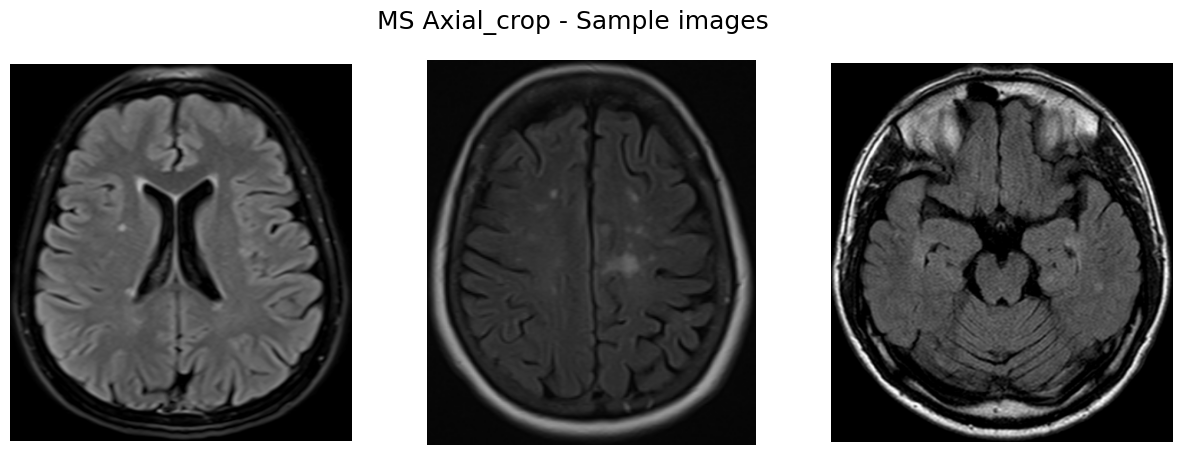

get_paths_and_labels()>>> Total images: 1652
get_data_loaders()>>> Training samples: 1321, Testing samples: 331


In [3]:
path, categories = data.get_dataset(relative_path="../../../data/raw")
classes = data.get_classes(path, categories)

image_paths, labels = data.get_paths_and_labels(path, classes)
train_transform, test_transform = data.get_transforms()

train_loader, test_loader, test_data = data.get_data_loaders(image_paths, labels, train_transform, test_transform)

## Model Instantiation

There are several different SE model variations relating to different SE placement options. These options are as follows:
- **architecture = "se_end"** : Single SE before the classifier (after layer 4)
- **architecture = "se_block_pre"**: SE built into each BasicBlock (before the shortcut)

In [5]:
# Using simplest SE model variation with a single SE module at the end of ResNet18 before classification
model = models.get_model(architecture="se_block_pre")

get_model()>>> 
 SEResNet18(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlockSEPre(
        (block): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (se): SEBlock(
          (avg_pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in

## Model Training

**Loss (BCEWithLogitsLoss)**: Binary cross-entropy loss combined with a sigmoid on logits. 
- Measures how well predicted probabilities match true binary labels
- Lower is better.<br>

**Loss & Acc**: Training metrics averaged over an epoch: Loss is mean training loss, Acc is training accuracy for that epoch.<br>

In [6]:
import torch.nn as nn
import torch.optim as optim

train_configs = {
    "base": {
        "num_epochs": 10,
        "lr": 1e-3,
        "parameters": "head",          # train only classifier head
        "optimiser": optim.Adam,
        "criterion": nn.BCEWithLogitsLoss(),
    },
    "fine_tune": {
        "num_epochs": 5,
        "lr": 1e-5,                    # lower LR for fine-tuning
        "parameters": "all",           # train backbone + head
        "optimiser": optim.Adam,
        "criterion": nn.BCEWithLogitsLoss(),
    },
}


[base] Epoch 1/10 - Loss: 0.5102 - Acc: 0.7464
[base] Epoch 2/10 - Loss: 0.4049 - Acc: 0.8085
[base] Epoch 3/10 - Loss: 0.3722 - Acc: 0.8229
[base] Epoch 4/10 - Loss: 0.3690 - Acc: 0.8319
[base] Epoch 5/10 - Loss: 0.3198 - Acc: 0.8562
[base] Epoch 6/10 - Loss: 0.3291 - Acc: 0.8554
[base] Epoch 7/10 - Loss: 0.3425 - Acc: 0.8418
[base] Epoch 8/10 - Loss: 0.3153 - Acc: 0.8622
[base] Epoch 9/10 - Loss: 0.3179 - Acc: 0.8584
[base] Epoch 10/10 - Loss: 0.3021 - Acc: 0.8698


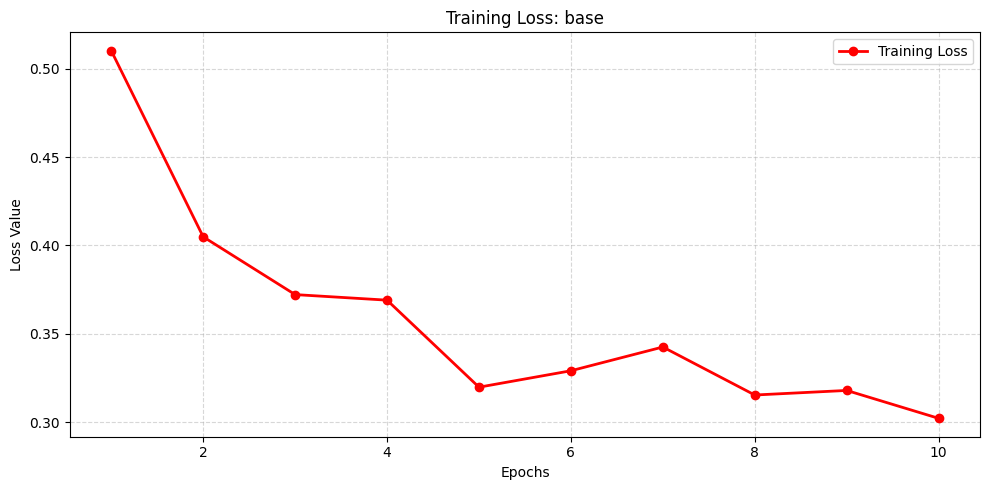

In [7]:
# Base training phase - only training classifier head
train_losses, train_accuracies = trainer.train_model(model, train_loader, config_name="base", train_configs=train_configs)
trainer.plot(train_losses, train_accuracies, config_name="base")

[fine_tune] Epoch 1/5 - Loss: 0.2780 - Acc: 0.8849
[fine_tune] Epoch 2/5 - Loss: 0.2128 - Acc: 0.9107
[fine_tune] Epoch 3/5 - Loss: 0.1905 - Acc: 0.9137
[fine_tune] Epoch 4/5 - Loss: 0.1618 - Acc: 0.9432
[fine_tune] Epoch 5/5 - Loss: 0.1372 - Acc: 0.9531


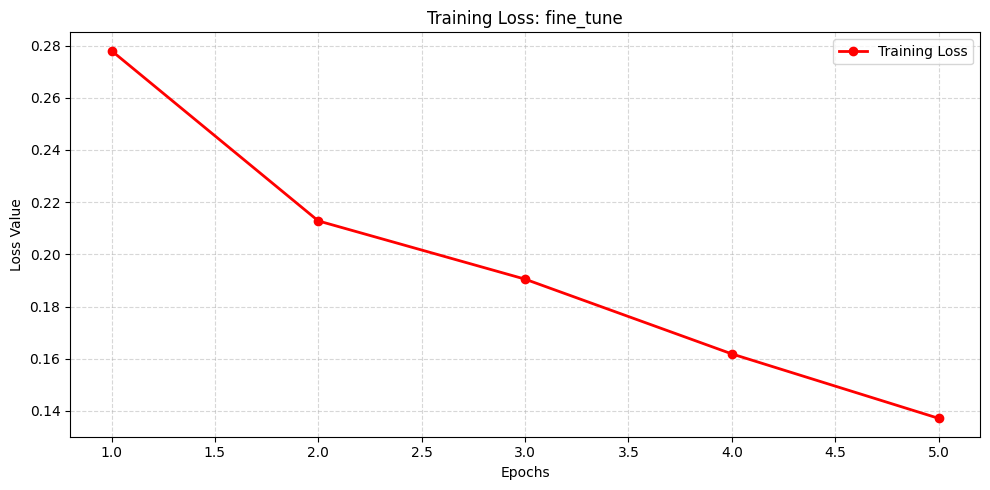

In [8]:
# Fine-tuning phase - training entire model
train_losses, train_accuracies = trainer.train_model(model, train_loader, config_name="fine_tune", train_configs=train_configs)
trainer.plot(train_losses, train_accuracies, config_name="fine_tune")

## Model Evaluation
**Accuracy**: Proportion of all predictions that are correct. 
- (TP + TN) / (TP + TN + FP + FN). 
- Good overall when classes are balanced.<br>

**Precision**: Of all examples predicted positive, the fraction that are actually positive. 
- TP / (TP + FP). 
- Measures false positive rate impact.<br>

**Recall (sensitivity)**: Of all actual positive examples, the fraction the model found. 
- TP / (TP + FN). 
- Measures false negative rate impact.<br>

**F1-score**: Harmonic mean of precision and recall: 
- 2 * (precision * recall) / (precision + recall). 
- Balances precision and recall.<br>

**Confusion_matrix**: 2x2 table for binary classification: 
- [[TN, FP],[FN, TP]] 
- Showing counts of true negatives, false positives, false negatives, true positives.<br>

**Classification_report**: Summary table per class containing precision, recall, f1-score and support (number of true instances for each class). 
- Also shows macro/weighted averages.<br>

In [9]:
evaluator.evaluate_model(model, test_loader)

C:\Users\markm\Workspace\ms-machine-learning-diagnosis\refactor\src\evaluator.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.float32).to(device)


Accuracy: 0.9154078549848943
Precision: 0.9180327868852459
Recall: 0.8615384615384616
Confusion Matrix:
 [[191  10]
 [ 18 112]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93       201
           1       0.92      0.86      0.89       130

    accuracy                           0.92       331
   macro avg       0.92      0.91      0.91       331
weighted avg       0.92      0.92      0.91       331



## Model Prediction Visualisation

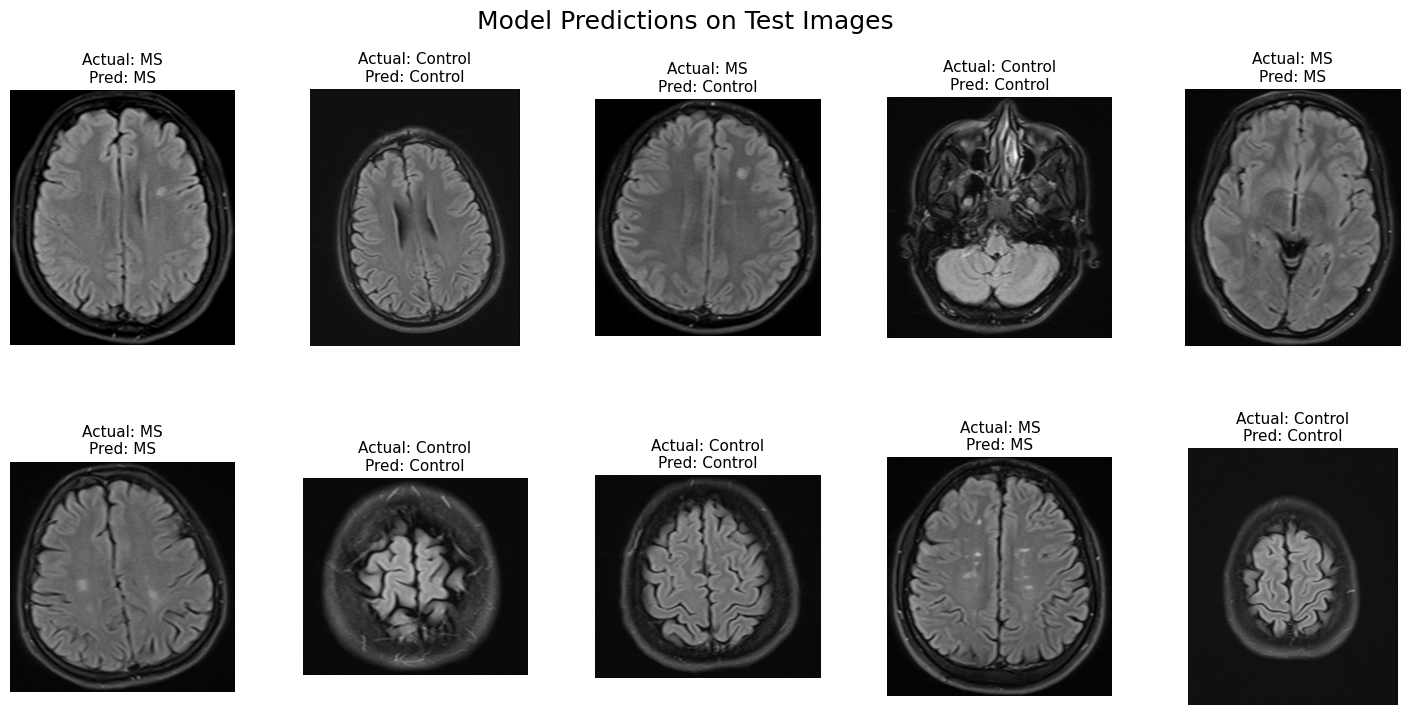

In [10]:
X_test, y_test = test_data
evaluator.predict_model(model, X_test, y_test, test_transform)